# ThermalTwin — One-Step Model Comparison

This notebook is a worked example of how to use the ThermalTwin toolbox end to end: load Netatmo data, engineer features, train several one-step-ahead indoor temperature predictors, and compare them.

It covers the `*_one_step` model family (`LinearOneStepPredictor`, `RidgeOneStepPredictor`, `NeuralOneStepPredictor`), which all consume the same flat, lag-based feature matrix produced by `FeatureEngineer`. See [`06_weather_only_comparison.ipynb`](06_weather_only_comparison.ipynb) for the windowed `*_weather_only` family.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from utils.data_loader import NetatmoDataLoader
from utils.feature_engineer import FeatureEngineer
from utils.split import DatasetSplitter
from utils.metrics import compute_metrics

from models.linear_one_step import LinearOneStepPredictor
from models.ridge_one_step import RidgeOneStepPredictor
from models.neural_one_step import NeuralOneStepPredictor

2026-07-16 10:27:13.480863: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-16 10:27:13.735092: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-16 10:27:13.735151: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-16 10:27:13.776003: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-16 10:27:13.873430: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-16 10:27:13.875305: I tensorflow/core/platform/cpu_feature_guard.cc:1

## 1. Load Data

In [2]:
DATA_DIR = Path("../data/csv")

loader = NetatmoDataLoader(DATA_DIR)

loader.station_names()

['Huis_19_06_2026_30min', 'Huis_19_06_2026_all', 'Huis_may_2025']

In [3]:
STATION = "Huis_19_06_2026_all"

df = loader.load_station(STATION)

df.head()

,datetime,temp_in,hum_in,temp_out,hum_out
0,2026-05-19 00:02:30,20.1,57,11.1,75.0
1,2026-05-19 00:07:30,20.1,56,11.0,75.0
2,2026-05-19 00:12:30,20.1,56,11.0,75.0
3,2026-05-19 00:17:30,20.1,56,11.0,75.0
4,2026-05-19 00:22:30,20.1,56,10.9,75.0


## 2. Feature Engineering

`FeatureEngineer` adds cyclical time-of-day/time-of-year features and lagged indoor/outdoor temperature columns, then builds the one-step-ahead target.

In [4]:
engineer = FeatureEngineer(
    indoor_lags=48,
    outdoor_lags=48,
)

engineer.summary()

FeatureEngineer
----------------
Target          : temp_in
Indoor lags     : 48
Outdoor lags    : 48
Total features  : 102


In [5]:
df_features = engineer.transform(df)

In [6]:
X, y = engineer.create_dataset(df_features)

print(X.shape)
print(y.shape)

(8745, 102)
(8745,)


## 3. Train / Validation / Test Split

`DatasetSplitter` splits chronologically (no shuffling), which is required for time series data.

In [7]:
splitter = DatasetSplitter()

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
) = splitter.split(X, y)

In [8]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6121, 102)
(1312, 102)
(1312, 102)


## 4. Train and Compare One-Step Models

All predictors share the same `BasePredictor` interface (`fit(X_train, y_train, X_val, y_val, **kwargs)`), so they can be trained in a single loop — the sklearn-based models simply ignore the neural-network-only kwargs (`epochs`, `verbose`).

In [9]:
models = {
    "Linear": LinearOneStepPredictor(),
    "Ridge": RidgeOneStepPredictor(alpha=1.0),
    "Neural": NeuralOneStepPredictor(n_features=X_train.shape[1]),
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train, X_val, y_val, epochs=30, verbose=0)

2026-07-16 10:27:36.008192: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-16 10:27:36.019181: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Training Linear...
Training Ridge...
Training Neural...


## 5. Evaluate

In [10]:
results = []
predictions = {}

for name, model in models.items():
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_mae, val_rmse = compute_metrics(y_val, y_val_pred)
    test_mae, test_rmse = compute_metrics(y_test, y_test_pred)

    results.append({
        "model": name,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
    })

    predictions[name] = y_test_pred

results_df = pd.DataFrame(results).set_index("model")

In [11]:
results_df

,val_mae,val_rmse,test_mae,test_rmse
model,,,,
Linear,0.089754,0.150847,0.091039,0.127097
Ridge,0.090540,0.153786,0.091693,0.128400
Neural,0.821423,1.087177,1.030659,1.320674


## 6. Visualize Results

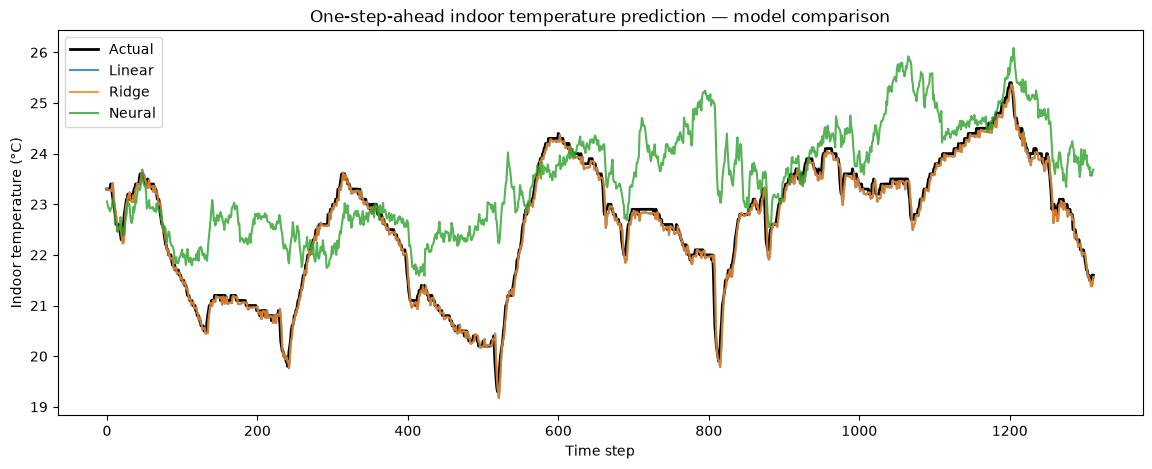

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(y_test.values, label="Actual", color="black", linewidth=2)

for name, pred in predictions.items():
    plt.plot(pred, label=name, alpha=0.8)

plt.legend()
plt.title("One-step-ahead indoor temperature prediction — model comparison")
plt.xlabel("Time step")
plt.ylabel("Indoor temperature (°C)")
plt.show()

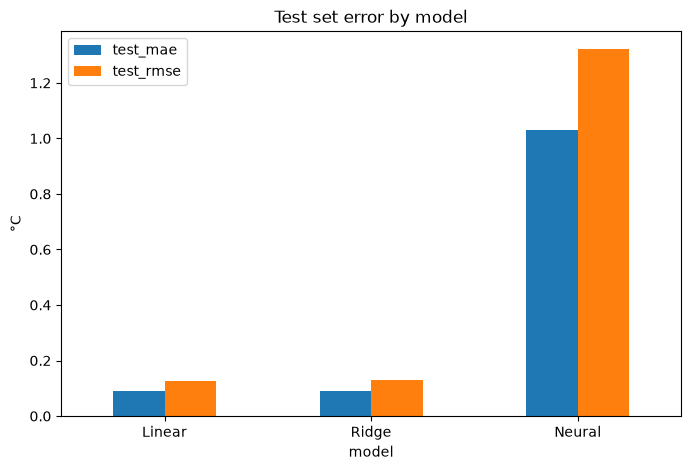

In [13]:
results_df[["test_mae", "test_rmse"]].plot(kind="bar", figsize=(8, 5))

plt.title("Test set error by model")
plt.ylabel("°C")
plt.xticks(rotation=0)
plt.show()

As also noted in the project [README](../README.md), the previous indoor temperature tends to be an extremely strong one-step-ahead predictor on its own, given the building's thermal inertia — keep that in mind when comparing these models against how much they actually improve on that.